<a href="https://colab.research.google.com/github/GdeJong404/MADS-ML-GinaDeJong/blob/portfolio/notebooks/4_tuning_networks/01_hypertuner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<td>
<a href="https://colab.research.google.com/github/raoulg/MADS-MachineLearning-course/blob/master/notebooks/4_tuning_networks/01_hypertuner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
</td>

In [1]:
import time
import numpy as np
from plotly import graph_objects as go
import matplotlib.pyplot as plt

from loguru import logger

import ray
from ray import tune, train

import torch
from torch import optim
from torch import nn

from pathlib import Path

%matplotlib inline
plt.style.use('dark_background')
# import plotly.io as pio
# pio.renderers.default = 'plotly_mimetype+notebook'

import visualize
DELETE = True # to delete the tunedir at the end of the notebook
start = time.time()

This is a general reference notebook to explore the use of ray tuner.
First, we define some global variables. This makes it easier to change the parameters for the full notebook at once and run everything.

Set the max_epochs to something like 10 (this will take longer, but you will get better results), and experiments to 18. This way, you will have a good way to compare gridsearch with the other tuners because gridsearch will do 3 * 6 = 18 experiments.

The reason I am setting this low is because i automated the testing of the notebook and it takes a long time to run all the experiments by default.


In [2]:
MAX_EPOCHS =     1
N_EXPERIMENTS =  2

# Train function and config

Let's define some dicts to log the results of the training.

In [3]:
"""
best_config:    configuration of the best parameters (dictates how the result will look/ behave/ ..)
"""

timer = {}
best_config = {}

We will need a training function. This is also implemented in the mltrainer, but I put it here to show you how the details work.

In [4]:
"""
trainstreamer               streamer refers to a pipeline to handle (real-time) data processing

model.train()               informs the model that it is in training mode. crucial for layers which express distinct behaviours depending on the status (train or eval)
train_loss: float = 0.0     initializes training loss variable (in this case type float which is pre-set to 0.0). If the result is (close to) 0, something's wrong
_                           in a loop '_' refers to 'do something in range(steps)'. The iterator value is not important, just that it should run some specific number of times
x, y = next(trainstreamer)  x and y equal the next iteration (of data) in trainstreamer → x is data, y is labels
optimizer.zero_grad()       needs to be initialized (before the backwards pass) to clear gradients of all optimized tensors to avoid o.a. gradient accumulation
                            source: https://www.geeksforgeeks.org/deep-learning/why-do-we-need-to-call-zerograd-in-pytorch/#why-zero_grad-is-necessary
yhat = model(x)             generate predictions
loss = lossfn(yhat, y)      calculate the loss by comparing the generated predictions with the actual labels (penalty for a model's incorrect predictions)
loss.backward()             calculates the gradients/ slope by determining how parameters contribute to the loss (error)
optimizer.step()            uses the calculated gradients/ slope to update the parameters
                            source: https://www.geeksforgeeks.org/deep-learning/pytorch-connection-between-lossbackward-and-optimizerstep/
train_loss += loss.item()   total training loss + loss value of a single item
"""

def train_fn(model, trainstreamer, lossfn, optimizer, steps):
    model.train()
    train_loss: float = 0.0
    for _ in range(steps):
        x, y = next(trainstreamer)
        optimizer.zero_grad()
        yhat = model(x)
        loss = lossfn(yhat, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    return train_loss

We validate on the validation set and return the loss.

In [5]:
"""
model.eval()            informs the model that it is in evaluation mode. crucial for layers which express distinct behaviours depending on the status
acc: float = 0.0        variable acc (accuracy) is set to type float and 0.0
with torch.no_grad()    loop that ensures that gradients aren't calculated of newly defined variables. Why? in order to update the weights without updating the gradients
                        because it can affect backpropagation
                        source: https://docs.pytorch.org/docs/2.12/generated/torch.no_grad.html
                                https://stackoverflow.com/questions/72504734/what-is-the-purpose-of-with-torch-no-grad
acc += metric(y, yhat)  a performance indicator is calculated using the labels and the predictions
acc /= steps            total accuracy is devided by the amount of steps taken
"""

def validate(model, validstreamer, lossfn, metric, steps):
    model.eval()
    valid_loss: float = 0.0
    acc: float = 0.0
    with torch.no_grad():
        for _ in range(steps):
            x, y = next(validstreamer)
            yhat = model(x)
            loss = lossfn(yhat, y)
            valid_loss += loss.item()
            acc += metric(y, yhat)
    acc /= steps
    return valid_loss, acc

Getting the data requires a bit extra care. Because we will run experiments in parallel on all the cpu's available, we well use FileLock to make sure that loading the data does not conflict.

Note we import functions inside the function we will later on pass to ray. This is because ray will serialize the function and send it to the workers. If we import the functions outside the function, the workers will not have access to them.

In [6]:
"""
create_factory()        with a factory, you can download the data, create datasets and provide the datasets wrapped in datastreamers
                        source: https://github.com/raoulg/mads_datasets
create_datastreamer()   a generator that yields batches of data
"""

def get_data(tune_dir):
    from filelock import FileLock
    from mads_datasets import DatasetFactoryProvider, DatasetType
    from mltrainer.preprocessors import PaddedPreprocessor
    from mads_datasets import DatasetFactoryProvider, DatasetType
    with FileLock(tune_dir / ".lock"):
        # we lock the datadir to avoid parallel instances trying to
        # access the datadir
        preprocessor = PaddedPreprocessor()
        gesturesdatasetfactory = DatasetFactoryProvider.create_factory(DatasetType.GESTURES)
        streamers = gesturesdatasetfactory.create_datastreamer(
            batchsize=32, preprocessor=preprocessor
        )
        train = streamers["train"]
        valid = streamers["valid"]
    return train, valid

We will use the same GRU model we used last lesson. You might improve this in a few ways (eg consider adding skip layers, conv1d, etc) but for clarity, lets keep it simple.

In [7]:
"""
GRUmodel        Gated Recurrent Unit. RNN which handles sequential data and at the same time reduces complexity of traditional RNNs
                source: https://www.geeksforgeeks.org/machine-learning/gated-recurrent-unit-networks/
x[:, -1, :]     specific part of a 3D tensor/ matrix (after reading underneith explanation, it is indeed the 'last step').
                  :   alle elementen uit de 1e dimensie
                 -1   het laatste element uit de 2e dimensie (wat alle samenvattende informatie uit de gehele reeks bevat)
                  :   alle elementen uit de 3e dimensie
other           - in nn.GRU worden allerlei values uit dict config gebruikt voor het instellen van parameters
                - last_step wordt door de lineaire laag gehaald die de features omzet in een voorspelling of score
"""

class GRUmodel(nn.Module):
    def __init__(
        self,
        config: dict,
    ) -> None:
        super().__init__()
        self.rnn = nn.GRU(
            input_size=config["input_size"],
            hidden_size=int(config["hidden_size"]),
            dropout=config["dropout"],
            batch_first=True,
            num_layers=int(config["num_layers"]),
        )
        self.linear = nn.Linear(int(config["hidden_size"]), config["output_size"])

    def forward(self, x):
        x, _ = self.rnn(x)
        last_step = x[:, -1, :]
        yhat = self.linear(last_step)
        return yhat

Now, we have all the ingredients we need to run the tuner.
We create a function that:
- loads the data with a lock
- creates the model
- trains the model
- validates the model
- reports the results to ray

In [8]:
"""
other         - this function calls/ incorporates all previous classes and functions to run the tuner
              - two lines have been adapted, because I got errors when trying to run the original code

"""

def tune_model(config: dict):
    from mltrainer.metrics import Accuracy

    # load data
    train, valid = get_data(config["tune_dir"])
    trainsteps = len(train)
    validsteps = len(valid)
    trainstreamer = train.stream()
    validstreamer = valid.stream()

    # create model with config
    model = GRUmodel(config)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = torch.nn.CrossEntropyLoss()
    metric = Accuracy()

    for _ in range(config["epochs"]):
        # train and validate
        train_loss = train_fn(model, trainstreamer, loss_fn, optimizer, trainsteps)
        valid_loss, accuracy = validate(model, validstreamer, loss_fn, metric, validsteps)

        # report to ray
        ray.tune.report({
        #ray.train.report({
            "valid_loss": valid_loss / validsteps,
            "train_loss": train_loss / trainsteps,
           #"accuracy" : accuracy,
            "accuracy" : accuracy.item() if hasattr(accuracy, "item") else accuracy,
            })


Let's try this, to see if everything works as expected.
Note that it typically does not make sense to use accelaration here; we will typically have 1 GPU, but 10 or 16 CPUS. We gain much more from parallelizing the experiments than we gain by running the model faster on a single GPU.

In [9]:
tune_dir = Path("logs/test/").resolve()

In [10]:
config = {
    "input_size": 3,
    "output_size": 20,
    "dropout": 0.1,
    "hidden_size": 64,
    "num_layers": 2,
    "epochs": MAX_EPOCHS,
    "tune_dir": tune_dir,
}

tune_model(config)

2026-06-01 15:00:07.355 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /root/.cache/mads_datasets/gestures
100%|██████████| 651/651 [00:00<00:00, 769.56it/s]
/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `report` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


# Key concepts

In the ray documentation https://docs.ray.io/en/latest/tune/key-concepts.html#tune-search-spaces you can find an overview of all the types of search spaces. I will copy an example here

```python
config = {
    "uniform": tune.uniform(-5, -1),  # Uniform float between -5 and -1
    "quniform": tune.quniform(3.2, 5.4, 0.2),  # Round to multiples of 0.2
    "loguniform": tune.loguniform(1e-4, 1e-1),  # Uniform float in log space
    "qloguniform": tune.qloguniform(1e-4, 1e-1, 5e-5),  # Round to multiples of 0.00005
    "randn": tune.randn(10, 2),  # Normal distribution with mean 10 and sd 2
    "qrandn": tune.qrandn(10, 2, 0.2),  # Round to multiples of 0.2
    "randint": tune.randint(-9, 15),  # Random integer between -9 and 15
    "qrandint": tune.qrandint(-21, 12, 3),  # Round to multiples of 3 (includes 12)
    "lograndint": tune.lograndint(1, 10),  # Random integer in log space
    "qlograndint": tune.qlograndint(1, 10, 2),  # Round to multiples of 2
    "choice": tune.choice(["a", "b", "c"]),  # Choose one of these options uniformly
    "func": tune.sample_from(
        lambda spec: spec.config.uniform * 0.01
    ),  # Depends on other value
    "grid": tune.grid_search([32, 64, 128]),  # Search over all these values
}
```
but in the docs you can find more details about every option

# Random search

Now, let's do a random search.

First, we define the search space. We can specify specific values, but also distributions.
For the hidden size, we will use randint, which will sample from a uniform distribution of integers.
The same for the number of layers.

The `tune.run` function runs the hypertuning. It will sample from the search space, and create a specific config for each experiment.

In [11]:

config = {
    "input_size": 3,
    "output_size": 20,
    "dropout": 0.05,
    "epochs": MAX_EPOCHS,
    "hidden_size": tune.randint(16, 512),
    "num_layers": tune.randint(1, 8),
    "tune_dir": tune_dir,
}

Let's test this!

In [12]:
tic = time.time()
analysis = tune.run(
    tune_model,
    config=config,
    metric="valid_loss",
    mode="min",
    storage_path=str(tune_dir),
    num_samples=N_EXPERIMENTS,
    stop={"training_iteration": MAX_EPOCHS},
    verbose=1,
)

timer["ray_random"] = time.time() - tic


2026-06-01 15:00:41,710	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-06-01 15:00:45,681	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.


+-------------------------------------------------------------------+
| Configuration for experiment     tune_model_2026-06-01_15-00-45   |
+-------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator            |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 2                                |
+-------------------------------------------------------------------+

View detailed results here: /content/logs/test/tune_model_2026-06-01_15-00-45
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-06-01_15-00-27_597367_130032/artifacts/2026-06-01_15-00-45/tune_model_2026-06-01_15-00-45/driver_artifacts`

Trial status: 2 PENDING
Current time: 2026-06-01 15:00:46. Total running time: 0s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+------------------------------------------------------------------+
| Trial name               status

(tune_model pid=130768) 2026-06-01 15:01:14.932 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /root/.cache/mads_datasets/gestures
 82%|████████▏ | 2123/2600 [00:00<00:00, 2390.48it/s]



Trial status: 2 RUNNING
Current time: 2026-06-01 15:01:16. Total running time: 30s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+------------------------------------------------------------------+
| Trial name               status       hidden_size     num_layers |
+------------------------------------------------------------------+
| tune_model_aae55_00000   RUNNING              202              4 |
| tune_model_aae55_00001   RUNNING               26              5 |
+------------------------------------------------------------------+


100%|██████████| 651/651 [00:00<00:00, 1297.95it/s]



Trial tune_model_aae55_00001 completed after 1 iterations at 2026-06-01 15:01:32. Total running time: 46s
+-------------------------------------------------+
| Trial tune_model_aae55_00001 result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time_this_iter_s                        31.4936 |
| time_total_s                            31.4936 |
| training_iteration                            1 |
| accuracy                                0.12188 |
| train_loss                              2.79814 |
| valid_loss                              2.49181 |
+-------------------------------------------------+


2026-06-01 15:01:45,862	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/content/logs/test/tune_model_2026-06-01_15-00-45' in 0.0073s.



Trial tune_model_aae55_00000 completed after 1 iterations at 2026-06-01 15:01:45. Total running time: 1min 0s
+-------------------------------------------------+
| Trial tune_model_aae55_00000 result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time_this_iter_s                        44.7762 |
| time_total_s                            44.7762 |
| training_iteration                            1 |
| accuracy                                0.27031 |
| train_loss                              2.37558 |
| valid_loss                              1.96494 |
+-------------------------------------------------+

Trial status: 2 TERMINATED
Current time: 2026-06-01 15:01:45. Total running time: 1min 0s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: aae55_00000 with valid_loss=1.9649388492107391 and params={'input_size': 3, 'output_size': 20, 'dropout': 0.05, 'epochs': 1, 'hidden_size': 202, 'num_layers': 4,

In [13]:
def plot_contour(df, x, y, z, start=0.90, end=1.0, size=0.01):
    fig = go.Figure()

    fig.add_trace(
        go.Contour(
            z=df[z],
            x=df[x],
            y=df[y],
            contours=dict(
                coloring='heatmap',
                showlabels=True,  # show labels on contours
                start=start,       # start of the contour range
                end=end,          # end of the contour range
                size=size,
            ),
            colorscale="plasma",
            colorbar=dict(
                title='Accuracy'
            )
        )
    )

    fig.add_trace(
        go.Scatter(
            x=df[x],
            y=df[y],
            mode='markers',
            marker=dict(
                color='black',
                size=8,
                symbol='circle'
            ),
            customdata=df['accuracy'],  # Pass accuracy values for hover text
            hovertemplate=(
                'Hidden Size: %{x}<br>'
                'Number of Layers: %{y}<br>'
                'Accuracy: %{customdata:.4f}<extra></extra>'
            ),
            name='Data Points'
        )
    )

    fig.update_layout(
        title="Contour Plot",
        xaxis_title="Hidden Size",
        yaxis_title="Number of Layers",
        xaxis=dict(showgrid=False),  # Remove x-axis grid lines
        yaxis=dict(showgrid=False),
        plot_bgcolor='white',        # Set background color to white
        paper_bgcolor='white'
    )

    fig.show()

In [14]:
all_results = analysis.results_df

In [15]:
random = analysis.results_df
plot_contour(random, "config/hidden_size", "config/num_layers", "accuracy")

As you can see, the search space is sort of randomly sampled.
Even though big parts are unexplored, it still looks like we find some hotspots.

In [16]:
best = analysis.get_best_config()
best["accuracy"] = analysis.best_result["accuracy"]
best_config["random"] = best

So, we searched the hyperparameter space. Problem is, these spaces potentially can get
pretty big. Let's imagine you have 10 hyperparameters, and every hyperparameter has 5
possible (relevant) values, you already have $5^{10}$ possible combinations, which is almost 10 million. Even if checking of every configuration would take just 1 second, it would take more than a 100 days to check them all...This
space can grow out of control pretty fast.

Lets look at the best results we found.

In [17]:
best

{'input_size': 3,
 'output_size': 20,
 'dropout': 0.05,
 'epochs': 1,
 'hidden_size': 202,
 'num_layers': 4,
 'tune_dir': PosixPath('/content/logs/test'),
 'accuracy': 0.27031248807907104}

In [18]:
"""
Herscheven omdat visualize vervelend doet
"""
#visualize.parallel_plot(analysis, columns) # --> AttributeError: module 'visualize' has no attribute 'parallel_plot'

# visualize.parallel_plot(analysis, columns)
import plotly.express as px

# 1. Haal de dataframe op uit jouw tune.run resultaat
df = analysis.dataframe()

# 2. Jouw gedefinieerde kolommen + de metriek voor de inkleuring
columns = ["config/hidden_size", "config/num_layers", "accuracy"]
# We voegen 'valid_loss' toe zodat je de prestaties op de assen ziet
dimensions = columns + ["valid_loss"]

# 3. De parallel plot aanmaken via Plotly Express
fig = px.parallel_coordinates(
    df,
    dimensions=dimensions,
    color="valid_loss",                  # Kleur de lijnen op basis van valid_loss
    color_continuous_scale=px.colors.sequential.Viridis, # Verloop van paars/blauw (laag) naar geel (hoog)
    title="Ray Tune Hyperparameter Parallel Plot",
)

# 4. Toon de interactieve grafiek
fig.show()

Note how the mean scores are sort of randomly distributed. This is a direct
effect of random guessing parameters.

# Grid search

We can do this more rigorous with a gridsearch.
The upside of this technique is that you will test every configuration.

A huge downside is the inefficiency. Also, you will run experiments with combinations that might be not very promising, but very slow, which is pretty inefficient.


One way to handle this is to use doubling as a strategy to scan the range: 16, 32, ..., 512. This is a bit more efficient.

Typically, this can be a good idea for a first scan, to get a rough idea of the space.
After you have done this, you can narrow your searchspace, and do a more fine grained search zoomed in on areas that seem promising.

In [19]:
config = {
    "input_size": 3,
    "output_size": 20,
    "dropout": 0.1,
    "epochs": MAX_EPOCHS,
    "hidden_size": tune.grid_search([16, 32, 64, 128, 256, 512]),
    "num_layers": tune.grid_search([2, 4, 8]),
    "tune_dir": tune_dir,
}

In [20]:

tic = time.time()

analysis = tune.run(
    tune_model,
    config=config,
    metric="valid_loss",
    mode="min",
    storage_path=str(tune_dir),
    stop={"training_iteration": MAX_EPOCHS},
    verbose=1,
)

timer["ray_grid"] = time.time() - tic

best = analysis.get_best_config()
best["accuracy"] = analysis.best_result["accuracy"]
best_config["grid"] = best

+-------------------------------------------------------------------+
| Configuration for experiment     tune_model_2026-06-01_15-05-58   |
+-------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator            |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 18                               |
+-------------------------------------------------------------------+

View detailed results here: /content/logs/test/tune_model_2026-06-01_15-05-58
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-06-01_15-00-27_597367_130032/artifacts/2026-06-01_15-05-58/tune_model_2026-06-01_15-05-58/driver_artifacts`

Trial status: 18 PENDING
Current time: 2026-06-01 15:05:58. Total running time: 0s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+------------------------------------------------------------------+
| Trial name               statu

(tune_model pid=132116) 2026-06-01 15:06:23.922 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /root/.cache/mads_datasets/gestures
 96%|█████████▋| 2508/2600 [00:02<00:00, 907.15it/s]



Trial status: 2 RUNNING | 16 PENDING
Current time: 2026-06-01 15:06:29. Total running time: 30s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+------------------------------------------------------------------+
| Trial name               status       hidden_size     num_layers |
+------------------------------------------------------------------+
| tune_model_653ed_00000   RUNNING               16              2 |
| tune_model_653ed_00001   RUNNING               32              2 |
| tune_model_653ed_00002   PENDING               64              2 |
| tune_model_653ed_00003   PENDING              128              2 |
| tune_model_653ed_00004   PENDING              256              2 |
| tune_model_653ed_00005   PENDING              512              2 |
| tune_model_653ed_00006   PENDING               16              4 |
| tune_model_653ed_00007   PENDING               32              4 |
| tune_model_653ed_00008   PENDING               64              4 |
| tune_model_653ed_00009   PEN

100%|██████████| 2600/2600 [00:02<00:00, 993.41it/s]
(tune_model pid=132117) 2026-06-01 15:06:25.868 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /root/.cache/mads_datasets/gestures
100%|██████████| 651/651 [00:00<00:00, 1051.72it/s]



Trial tune_model_653ed_00001 completed after 1 iterations at 2026-06-01 15:06:33. Total running time: 34s
+-------------------------------------------------+
| Trial tune_model_653ed_00001 result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time_this_iter_s                        19.6143 |
| time_total_s                            19.6143 |
| training_iteration                            1 |
| accuracy                                0.10312 |
| train_loss                              2.88945 |
| valid_loss                              2.62632 |
+-------------------------------------------------+

Trial tune_model_653ed_00000 completed after 1 iterations at 2026-06-01 15:06:37. Total running time: 38s
+-------------------------------------------------+
| Trial tune_model_653ed_00000 result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time

...

Trial status: 15 TERMINATED | 2 RUNNING | 1 PENDING
Current time: 2026-06-01 15:14:30. Total running time: 8min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 653ed_00011 with valid_loss=1.684517616033554 and params={'input_size': 3, 'output_size': 20, 'dropout': 0.1, 'epochs': 1, 'hidden_size': 512, 'num_layers': 4, 'tune_dir': PosixPath('/content/logs/test')}
+-------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name               status         hidden_size     num_layers     iter     total time (s)     valid_loss     train_loss     accuracy |
+-------------------------------------------------------------------------------------------------------------------------------------------+
| tune_model_653ed_00015   RUNNING                128              8                                                                        |
| tune_model_653ed_00016   RUNNING            

(tune_model pid=134940) 2026-06-01 15:15:10.216 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /root/.cache/mads_datasets/gestures
100%|██████████| 651/651 [00:00<00:00, 1357.75it/s]


Trial status: 16 TERMINATED | 2 RUNNING
Current time: 2026-06-01 15:15:30. Total running time: 9min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 653ed_00011 with valid_loss=1.684517616033554 and params={'input_size': 3, 'output_size': 20, 'dropout': 0.1, 'epochs': 1, 'hidden_size': 512, 'num_layers': 4, 'tune_dir': PosixPath('/content/logs/test')}
+-------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name               status         hidden_size     num_layers     iter     total time (s)     valid_loss     train_loss     accuracy |
+-------------------------------------------------------------------------------------------------------------------------------------------+
| tune_model_653ed_00016   RUNNING                256              8                                                                        |
| tune_model_653ed_00017   RUNNING                512     

2026-06-01 15:18:30,487	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/content/logs/test/tune_model_2026-06-01_15-05-58' in 0.0176s.



Trial tune_model_653ed_00017 completed after 1 iterations at 2026-06-01 15:18:30. Total running time: 12min 32s
+-------------------------------------------------+
| Trial tune_model_653ed_00017 result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time_this_iter_s                        212.428 |
| time_total_s                            212.428 |
| training_iteration                            1 |
| accuracy                                0.25469 |
| train_loss                              2.44007 |
| valid_loss                              1.94292 |
+-------------------------------------------------+

Trial status: 18 TERMINATED
Current time: 2026-06-01 15:18:30. Total running time: 12min 32s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: 653ed_00011 with valid_loss=1.684517616033554 and params={'input_size': 3, 'output_size': 20, 'dropout': 0.1, 'epochs': 1, 'hidden_size': 512, 'num_layers':

In [69]:
import pandas as pd
all_results = pd.concat([all_results, analysis.results_df])

In [70]:
grid = analysis.results_df
plot_contour(grid, "config/hidden_size", "config/num_layers", "accuracy", start=0.7)

As you can see, we get a systematic scan, but large parts of the space are still unexplored, and we also explored parts that are really not very promising.

In [78]:
"""
herschreven omdat niets in visualize herkend wordt..
"""

# visualize.parallel_plot(analysis, columns)
import plotly.express as px

# 1. Haal de dataframe op uit jouw tune.run resultaat
df = analysis.dataframe()

# 2. Jouw gedefinieerde kolommen + de metriek voor de inkleuring
columns = ["config/hidden_size", "config/num_layers", "accuracy"]
# We voegen 'valid_loss' toe zodat je de prestaties op de assen ziet
dimensions = columns + ["valid_loss"]

# 3. De parallel plot aanmaken via Plotly Express
fig = px.parallel_coordinates(
    df,
    dimensions=dimensions,
    color="valid_loss",                  # Kleur de lijnen op basis van valid_loss
    color_continuous_scale=px.colors.sequential.Viridis, # Verloop van paars/blauw (laag) naar geel (hoog)
    title="Ray Tune Hyperparameter Parallel Plot",
)

# 4. Toon de interactieve grafiek
fig.show()

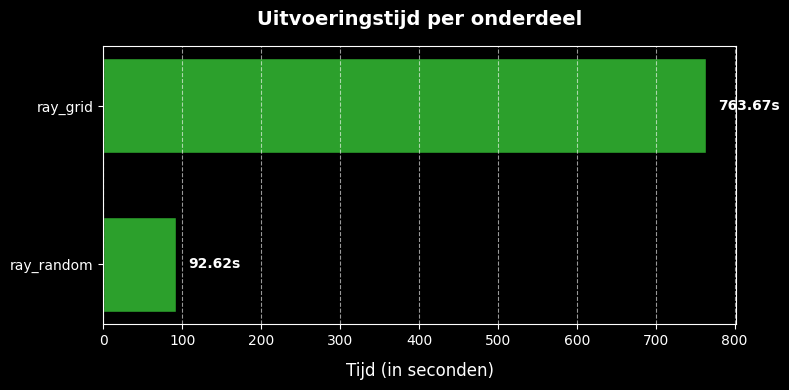

In [79]:
"""
Herschreven omdat niets van module visualize herkend wordt.
"""

# visualize.plot_timers(timer)
import matplotlib.pyplot as plt

# 1. Splits de dictionary op in namen (keys) en tijden (values)
labels = list(timer.keys())
durations = list(timer.values())

# 2. Maak de plot aan
fig, ax = plt.subplots(figsize=(8, 4))

# Teken horizontale staven
bars = ax.barh(labels, durations, color="#2ca02c", edgecolor="black", height=0.6)

# 3. Styling en opmaak
ax.set_title("Uitvoeringstijd per onderdeel", fontsize=14, pad=15, fontweight="bold")
ax.set_xlabel("Tijd (in seconden)", fontsize=12, labelpad=10)
ax.grid(axis="x", linestyle="--", alpha=0.6)

# Voeg de exacte tijd als tekst toe aan het uiteinde van elke staaf
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max(durations) * 0.02),  # Een kleine marge rechts van de staaf
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}s",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

# Zorg dat de labels goed leesbaar zijn en toon de plot
plt.tight_layout()
plt.show()

# Bayes

Now, we improve the search algorithm with a bayesian optimization.

Note that the bayesian search algorithm will only work with continuous parameters. This is a problem for the number of layers, which is a discrete parameter. I fixed this by simply casting the parameters to an integer inside the model, which is not very elegant but it works.

In [96]:
pip install -U bayesian-optimization==1.5.1

In [97]:
# pip install -q bayesian-optimization==1.5.1 #other version did not support attribute UtilityFunction
from bayes_opt import BayesianOptimization, UtilityFunction

#from bayes_opt import UtilityFunction
from ray.tune.search.bayesopt import BayesOptSearch

bayesopt = BayesOptSearch(metric="valid_loss", mode="min")


config = {
    "input_size": 3,
    "output_size": 20,
    "dropout": 0.1,
    "epochs": MAX_EPOCHS,
    "hidden_size": tune.uniform(16, 512),
    "num_layers": tune.uniform(1, 8),
    "tune_dir": tune_dir,
}

tic = time.time()

analysis = tune.run(
    tune_model,
    config=config,
    metric="valid_loss",
    mode="min",
    storage_path=str(tune_dir),
    num_samples=N_EXPERIMENTS,
    stop={"training_iteration": MAX_EPOCHS},
    search_alg=bayesopt,
    verbose=1,
)

timer["ray_bayes"] = time.time() - tic

best = analysis.get_best_config()
best["accuracy"] = analysis.best_result["accuracy"]
best_config["bayes"] = best


ImportError: cannot import name 'UtilityFunction' from 'bayes_opt' (/usr/local/lib/python3.12/dist-packages/bayes_opt/__init__.py)

In [ ]:
best

In [ ]:
all_results = pd.concat([all_results, analysis.results_df])

In [ ]:
bayes = analysis.results_df
plot_contour(bayes, "config/hidden_size", "config/num_layers", "accuracy", start=0.7)

As you can see, bayes really focuses on the promising areas. It is much more efficient than random search, and also more efficient than grid search.
We have set the `random_search_steps` to 5, this means that we will do 5 random searches first, to get a good initial idea of the space. As you can see, 5 is a bit low, because it might lead to premature converging to a local optimum. You can increase this number to get a better initial idea of the space, but you will also need to increase the number of iterations after the initial random scan.

In [ ]:
visualize.parallel_plot(analysis, columns)

In [ ]:
visualize.plot_timers(timer)

In [ ]:
import pandas as pd

pd.DataFrame.from_dict(best_config, orient="index")


# Hyperband

Hyperband aborts runs early. Configs that are unpromising are abandoned before they complete.

In [ ]:
from ray.tune.schedulers import AsyncHyperBandScheduler

scheduler = AsyncHyperBandScheduler(
    time_attr="training_iteration", grace_period=1, reduction_factor=3, max_t=MAX_EPOCHS
)

config = {
    "input_size": 3,
    "output_size": 20,
    "dropout": 0.1,
    "epochs": MAX_EPOCHS,
    "hidden_size": tune.randint(16, 512),
    "num_layers": tune.randint(1, 8),
    "tune_dir": tune_dir,
}

tic = time.time()
analysis = tune.run(
    tune_model,
    config=config,
    metric="valid_loss",
    mode="min",
    storage_path=str(tune_dir),
    num_samples=N_EXPERIMENTS,
    stop={"training_iteration": MAX_EPOCHS},
    scheduler=scheduler,
    verbose=1,
)

timer["ray_hyperband"] = time.time() - tic

best = analysis.get_best_config()
best["accuracy"] = analysis.best_result["accuracy"]
best_config["hyperband"] = best


If you study the iter column, you will see that some runs have been stopped early. This is exactly the point of hyperband: it tries to allocate resources to the most promising configurations.

The downside of this, is that if you try to get a good view of the space, you get distorted results because comparing a model that has trained just 1 or 3 epochs with a model that has trained 100 epochs is not very fair...

In [ ]:
all_results = pd.concat([all_results, analysis.results_df])

In [ ]:
hyperband = analysis.results_df
plot_contour(hyperband, "config/hidden_size", "config/num_layers", "accuracy", start=0.7)

In [ ]:
visualize.parallel_plot(analysis, columns)


But note that it is faster! This means you could do more runs in the same time, which might be a good tradeoff!
Typically you will get better results if you scan the searchspace better by doing more runs, aborting the ones that are not promising and going on with the ones that seem to yield good results.

In [ ]:
visualize.plot_timers(timer)


In [ ]:
pd.DataFrame.from_dict(best_config, orient="index")

# Hyperbayes

It is possible to combine Hyperband with Bayesian optimization, implemented as `TuneBOHB` in ray.
However, `TuneBOHB` in ray is dependent on `hpbandster`, which is not maintained anymore.
Unfortunately, a dependency of `hpbandster` is `netifaces`, which is also not maintained anymore.
While `netifaces` does work on some hardware, it fails to build on some other hardware, which is a problem.

To still use BOHB type algoritms, I am planning to implement either SMAC3 or BEHB in the future.


# HyperOpt
HyperOpt provides gradient/derivative-free optimization. They implemented TPE, which stands for Tree-structured Parzen Estimator. This is a bayesian optimization algorithm that uses a tree to model the distribution of the objective function. The main advantage is that TPE also works with discrete parameters and conditional search spaces which is a problem for the bayesian optimization.

For example, you could do things like this:
```python
conditional_space = {
    "activation": hp.choice(
        "activation",
        [
            {"activation": "relu", "mult": hp.uniform("mult", 1, 2)},
            {"activation": "tanh"},
        ],
    ),
}
```

Where you have a discrete parameter `activation` that has a conditional parameter `mult`. This means that if you choose `relu`, you also need to set `mult`, but if you choose `tanh`, you do not need to set `mult`. See [documentation of ray](https://docs.ray.io/en/latest/tune/examples/hyperopt_example.html) for more details.

In [ ]:
from ray.tune.search.hyperopt import HyperOptSearch
search = HyperOptSearch()

scheduler = AsyncHyperBandScheduler(
    time_attr="training_iteration", grace_period=1, reduction_factor=3, max_t=MAX_EPOCHS
)

In [ ]:
config = {
    "input_size": 3,
    "output_size": 20,
    "dropout": 0.1,
    "epochs": MAX_EPOCHS,
    "hidden_size": tune.randint(16, 512),
    "num_layers": tune.randint(1, 8),
    "tune_dir": tune_dir,
}

tic = time.time()
analysis = tune.run(
    tune_model,
    config=config,
    metric="valid_loss",
    mode="min",
    storage_path=str(tune_dir),
    num_samples=N_EXPERIMENTS,
    stop={"training_iteration": MAX_EPOCHS},
    search_alg=search,
    scheduler=scheduler,
    verbose=1,
)

timer["ray_hyperopt"] = time.time() - tic

best = analysis.get_best_config()
best["accuracy"] = analysis.best_result["accuracy"]
best_config["hyperopt"] = best


In [ ]:
all_results = pd.concat([all_results, analysis.results_df])

In [ ]:
hyperbayes = analysis.results_df
plot_contour(hyperbayes, "config/hidden_size", "config/num_layers", "accuracy", start=0.3, size=0.05)


This model combines bayesian optimization with hyperband. This is a good idea, because it combines the efficiency of bayesian optimization with the speed of hyperband.

In [ ]:
visualize.parallel_plot(analysis, columns)


In [ ]:
visualize.plot_timers(timer)


In [ ]:
pd.DataFrame.from_dict(best_config, orient="index")


In [ ]:
contour = all_results[all_results["training_iteration"] == MAX_EPOCHS]
plot_contour(contour, "config/hidden_size", "config/num_layers", "accuracy", start=0.8)

In [ ]:
stop = time.time() - start
print(stop)

In [ ]:
if DELETE:
    import shutil
    shutil.rmtree(tune_dir)
